# Lab 3 - Making a SkewT from scratch

In [125]:
#import statements
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
#import metpy.calc as mpcalc
#from metpy.cbook import get_test_data
from scipy.integrate import solve_ivp


In [ ]:
#defining constants
epsilon = 0.622  # Ratio of the gas constants for dry air and water vapor
R_d = 287.05  # Gas constant for dry air (J/(kg·K))
R_v = 461.5  # Gas constant for water vapor (J/(kg·K))
c_pd = 1005.7  # Specific heat capacity of dry air at constant pressure (J/(kg·K))
L_v = 2.5e6  # Latent heat of vaporization (J/kg)
g = 9.81  # Gravitational acceleration (m/s^2)

#defining helper functions for skewt calculations
def e_s(temperature): #calculate the saturation vapor pressure over liquid water (in hPa) using the Bolton formula.
    return 6.112 * np.exp((17.67 * temperature) / (temperature + 243.5))

def r_s(temperature, pressure): #calculate the saturation mixing ratio (in kg/kg) using the saturation vapor pressure and pressure.
    return epsilon * e_s(temperature) / (pressure - e_s(temperature))

def moist_adiabatic_lapse_rate(pressure, temperature): 
    temp_k = temperature[0] + 273.15 
    
    r_s_value = r_s(temperature[0], pressure)
    
    numerator = 1 + (L_v * r_s_value) / (R_d * temp_k)
    denominator = 1 + (L_v**2 * r_s_value) / (c_pd * R_v * temp_k**2)
    dT_dz = (g / c_pd) * (numerator / denominator)
    
    dT_dP = (R_d * temp_k) / (pressure * g) * dT_dz
    
    return [dT_dP]


In [ ]:
#skewing the temperature profile for skew-T log-P diagram
def skewT(temperature, pressure, skew=-20, ):
    """
    Skew the temperature axis for a Skew-T log-P plot.

    Parameters
    ----------
    temperature : array-like
        Temperature values in degrees Celsius.
    pressure : array-like
        Pressure values in hPa.
    skew : float, optional
        Amount of skewing, by default -20.
    """
    return temperature + skew * np.log(pressure / 1000.0)

def plot_skewT(temperature, pressure, dewpoint, wind=None):
    """
    Plot a Skew-T log-P diagram.

    Parameters
    ----------
    temperature : array-like
        Temperature values in degrees Celsius.
    pressure : array-like
        Pressure values in hPa.
    dewpoint : array-like
        Dewpoint temperature values in degrees Celsius, by default None.
    wind : array-like, optional
        Wind speed and direction values, by default None.
    """
    #setting up figure to plot on
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Skew the temperature profile using observed temperature and pressure values from a radiosonde
    skewed_temp = skewT(temperature, pressure)
    
    # Plot temperature profile
    ax.plot(skewed_temp, pressure, color='red', label='Temperature')

    #plotting slanted isotherms every 10°C
    pressure_range_isotherms = np.arange(1000, 0, -100)
    isotherms = np.arange(-80, 50, 10) #setting a range greater than given in problem to cover top left corner of figure
    for temp in isotherms:
        skewed_isotherm = skewT(np.full_like(pressure_range_isotherms, temp), pressure_range_isotherms)
        ax.plot(skewed_isotherm, pressure_range_isotherms, color='gray', linewidth=0.5)
    
    # Skew the dewpoint profile using observed dewpoint and pressure values from a radiosonde
    skewed_dewpoint = skewT(dewpoint, pressure)

    #Plot the dew point profile
    ax.plot(skewed_dewpoint, pressure, color='green', label='Dewpoint')

    #dry adiabats
    temp_range = np.arange(-40, 250, 12)
    pressure_range_dry = np.arange(1000, 0,-100)
    for temp in temp_range:
        temp_k = temp + 273.15  
        p0 = 1000
        theta = temp_k * (pressure_range_dry / p0) ** (R_d/c_pd)
        skewed_theta_c = skewT(theta - 273.15, pressure_range_dry)
        ax.plot(skewed_theta_c, pressure_range_dry, color='orange', linewidth=0.5)

   

    #moist_ad_temps = 20 
    #pressure_range_moist = np.arange(1000, 90, -10)
    #p_span = (1000, 100)

    #solve_moist_ad = solve_ivp(moist_adiabatic_lapse_rate, t_span=p_span, y0=[moist_ad_temps], t_eval=pressure_range_moist)
    #temp_c_profile = solve_moist_ad.y[0]

    #skewed_x = skewT(temp_c_profile, pressure_range_moist)
    #ax.plot(skewed_x, pressure_range_moist, color='blue', linewidth=0.5)

    moist_ad_temps = temp_range
    pressure_range_moist = np.arange(1000, 90, -10)
    p_span = (1000, 100)
    for temp in temp_range:
        solve_moist_ad = solve_ivp(moist_adiabatic_lapse_rate, t_span=p_span, y0=[moist_ad_temps[temp]], t_eval=pressure_range_moist)
        temp_c_profile = solve_moist_ad.y[0]
    
        skewed_moist_ad = skewT(temp_c_profile, pressure_range_moist)
        ax.plot(skewed_moist_ad, pressure_range_moist, color='blue', linewidth=0.5)
    
    
    #Y-axis adjustments
    ax.set_yscale('log') #making axis log-scale
    ax.invert_yaxis() #inverting the axis to put highest pressure at the bottom
    ax.yaxis.set_major_formatter('{x:.0f}') #formatting the pressure labels correctly
    ax.yaxis.set_minor_formatter('{x:.0f}')
    ax.grid(which='minor', axis='y', color='gray') #adding horizontal lines for each pressure level
    ax.set_ylim(1000, 100) #setting y-axis limits based on assignment instructions
    ax.set_ylabel('Pressure (hPa)') #adding label to y-axis

    #X-axis adjustments
    ax.set_xlim(-40, 50) #setting y-axis limits based on assignment instructions
    ax.set_xlabel('Temperature (°C)') #adding label to x-axis
    
    
    
    # Set labels and title
    ax.set_title('Skew-T log-P Diagram')
    
    
    plt.show()

In [120]:
#getting test data for SkewT using data from the wyoming upper air site (ADD SPECIFIC TIME, DATE, AND LOCATION)
test_data = pd.read_csv('data/2026092400-72357.csv') #reading in the csv file generated from the site


IndexError: index -40 is out of bounds for axis 0 with size 25

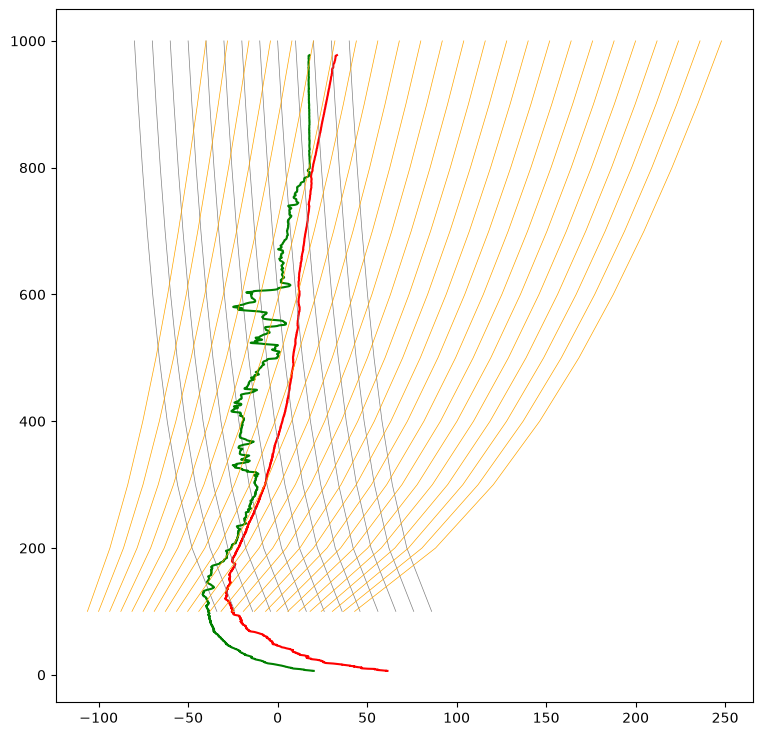

In [226]:
plot_skewT(test_data.temperature_C, test_data.pressure_hPa, test_data['dew point temperature_C'])

In [207]:
moist_ad_temps = 10 + 273.15
pressure_range_moist = np.arange(1000, 90, -10)
p_span = (1000, 100)
solve_moist_ad = solve_ivp(moist_adiabatic_lapse_rate, t_span=p_span, y0=[moist_ad_temps], t_eval=pressure_range_moist)
solve_moist_ad

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [1000  990 ...  110  100]
        y: [[ 2.831e+02  2.831e+02 ...  2.816e+02  2.816e+02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 26
     njev: 0
      nlu: 0

In [216]:
solve_moist_ad.y[0]

array([  10.        ,    9.56158321,    9.11678913,    8.66543549,
          8.20730246,    7.74212918,    7.26974577,    6.78997298,
          6.30261633,    5.80746606,    5.30429716,    4.79286937,
          4.27292716,    3.74419976,    3.20640115,    2.65923002,
          2.10236983,    1.53548879,    0.95823983,    0.37026064,
         -0.22882634,   -0.83941395,   -1.46191026,   -2.09673862,
         -2.74433761,   -3.40516109,   -4.07967817,   -4.7683732 ,
         -5.47174581,   -6.19031087,   -6.92459852,   -7.67515413,
         -8.44253836,   -9.22732772,  -10.03048831,  -10.85288405,
        -11.69505501,  -12.55756587,  -13.44100595,  -14.34598921,
        -15.27315422,  -16.2231642 ,  -17.196707  ,  -18.19449508,
        -19.21726556,  -20.26578018,  -21.34082529,  -22.44321192,
        -23.57377568,  -24.73337683,  -25.92290028,  -27.14325555,
        -28.39537679,  -29.6802228 ,  -30.99877699,  -32.35204741,
        -33.74106675,  -35.16689231,  -36.63060604,  -38.13331

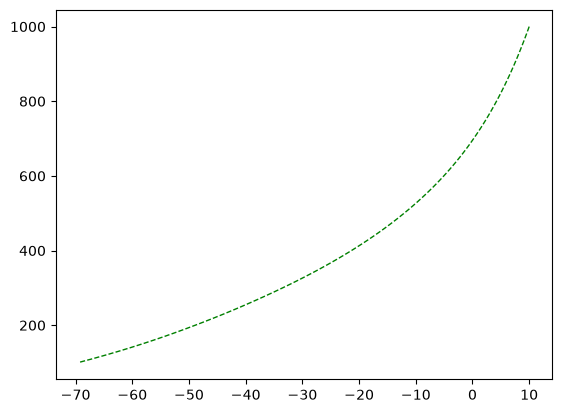

In [211]:

def e_s(temperature): #calculate the saturation vapor pressure over liquid water (in hPa) using the Bolton formula.
    return 6.112 * np.exp((17.67 * temperature) / (temperature + 243.5))

def r_s(temperature, pressure): 
    return epsilon * e_s(temperature) / (pressure - e_s(temperature))

def moist_adiabatic_lapse_rate(pressure, temperature): 
    temp_k = temperature[0] + 273.15 
    
    r_s_value = r_s(temperature[0], pressure)
    
    numerator = 1 + (L_v * r_s_value) / (R_d * temp_k)
    denominator = 1 + (L_v**2 * r_s_value) / (c_pd * R_v * temp_k**2)
    dT_dz = (g / c_pd) * (numerator / denominator)
    
    dT_dP = (R_d * temp_k) / (pressure * g) * dT_dz
    
    return [dT_dP]

moist_ad_temps = 10 
pressure_range_moist = np.arange(1000, 90, -10)
p_span = (1000, 100)

solve_moist_ad = solve_ivp(moist_adiabatic_lapse_rate, t_span=p_span, y0=[moist_ad_temps], t_eval=pressure_range_moist)
temp_c_profile = solve_moist_ad.y[0]

skewed_x = skewT(temp_c_profile, pressure_range_moist)
plt.plot(skewed_x, pressure_range_moist, color='green', linewidth=1, linestyle='--')

## Written answers

1) Why does the moist adiabatic lapse rate, $\Gamma_m=-\frac{dT}{dz}$, generally increase as a saturated parcel
ascends and cools?

2. At a fixed pressure, how and why does $\Gamma_m$ differ between warmer and colder moist adiabats?

3. Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What
does this test teach you about the value of skewing? No need to show your tests; just describe your
interpretations.

4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful.
Refer to specific pressure levels or layers and explain the physical significance of each feature.

5. What was the most challenging step for this lab? How did you navigate it, and what was the solution?
If you leaned on GenAI tools, how did they contribute to your work and how did you check the
information they provided?